# Task 3 - Cleaning Data

**Dataset:** `messy_customer_data.csv`

The dataset contains some common data quality problems such as missing values, duplicate rows, inconsistent text, different date formats, currency symbols and unusual numeric values.

The goal of this notebook is to clean the data step by step and create a separate analysis-ready CSV. The original messy CSV is not changed.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load the dataset



In [2]:
df_raw = pd.read_csv("messy_customer_data.csv", dtype="string")

print("Shape of dataset:", df_raw.shape)
df_raw.head(10)

Shape of dataset: (315, 9)


,CustomerID,Name,Gender,Age,JoinDate,Department,Salary,PurchaseAmount,Email
0,1074,James Brown,Male,40.0,26 Apr 2017,it,<NA>,268.49,james.brown@example.com
1,1270,David Smith,Male,61.0,<NA>,Marketing,"$32,390.12",48.4,david.smith@example.com
2,1031,Charles Lopez,FEMALE,43.0,2015/12/14,SALES,"$52,507.63",67.3,charles.lopez@example.com
3,1038,Susan Davis,M,24.0,2016-03-05,Finance,"$61,724.86",27.67,susan.davis@example.com
4,1169,Karen Garcia,male,33.0,02 May 2020,IT,"$48,152.93",39.77,karen.garcia@example.com
5,1071,Karen Brown,Female,32.0,2017-03-22,Sales,"$54,465.84",6200.0,karen.brown@example.com
6,1172,Richard Rodriguez,Female,27.0,2020/06/06,HR,"$54,096.22",224.06,richard.rodriguez@example.com
7,1089,Joseph Williams,female,29.0,10-17-2017,Marketing,"$58,442.23",655.2,joseph.williams@example.com
8,1281,David Smith,Male,46.0,22 Nov 2023,finance,"$53,727.24",126.96,david.smith@example.com
9,1067,Mary Rodriguez,F,46.0,02-04-2017,IT,"$79,253.12",21.06,mary.rodriguez@example.com


## 3. Data quality check

In [3]:
print("Null values in each column:")
print(df_raw.isna().sum())

print("\nExact duplicate rows:", df_raw.duplicated().sum())
print("Duplicate CustomerID values:", df_raw["CustomerID"].duplicated().sum())

print("\nData types before cleaning:")
print(df_raw.dtypes)

Null values in each column:
CustomerID         0
Name               0
Gender             0
Age               13
JoinDate           8
Department         0
Salary            12
PurchaseAmount     0
Email              9
dtype: int64

Exact duplicate rows: 14
Duplicate CustomerID values: 19

Data types before cleaning:
CustomerID        string
Name              string
Gender            string
Age               string
JoinDate          string
Department        string
Salary            string
PurchaseAmount    string
Email             string
dtype: object


In [4]:
print("Gender values:")
print(sorted(df_raw["Gender"].dropna().unique().tolist()))

print("\nDepartment values:")
print(sorted(df_raw["Department"].dropna().unique().tolist()))

print("\nSome JoinDate values:")
print(df_raw["JoinDate"].dropna().head(10).tolist())

print("\nSome Salary values:")
print(df_raw["Salary"].dropna().head(5).tolist())

Gender values:
[' Male', 'F', 'FEMALE', 'Female', 'Female ', 'M', 'MALE', 'Male', 'female', 'male']

Department values:
['Finance', 'HR', 'IT', 'Marketing', 'SALES', 'Sales', 'finance ', 'hr', 'it', 'marketing', 'sales']

Some JoinDate values:
['26 Apr 2017', '2015/12/14', '2016-03-05', '02 May 2020', '2017-03-22', '2020/06/06', '10-17-2017', '22 Nov 2023', '02-04-2017', '03/12/2019']

Some Salary values:
['$32,390.12', '$52,507.63', '$61,724.86', '$48,152.93', '$54,465.84']


In [5]:
age_check = pd.to_numeric(df_raw["Age"], errors="coerce")
purchase_check = pd.to_numeric(df_raw["PurchaseAmount"], errors="coerce")

print("Age range:", age_check.min(), "to", age_check.max())
print("Invalid ages (<0 or >100):", ((age_check < 0) | (age_check > 100)).sum())
print("PurchaseAmount range:", purchase_check.min(), "to", purchase_check.max())

Age range: -5.0 to 64.0
Invalid ages (<0 or >100): 3
PurchaseAmount range: 0.06 to 6200.0


### Initial observations

There are missing values in Age, JoinDate, Salary and Email. There are also exact duplicate rows. Gender and Department use different cases and short forms. Dates are stored in different formats and Salary contains `$` and commas. Age and PurchaseAmount also contain unusual values that need to be checked.

## 4. Remove duplicate rows



In [6]:
df = df_raw.copy()

rows_before = len(df)
duplicates_removed = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows removed:", duplicates_removed)
print("Rows after removing duplicates:", len(df))

Duplicate rows removed: 14
Rows after removing duplicates: 301


## 5. Standardise text columns


In [7]:
df["Gender"] = df["Gender"].str.strip().str.lower()
df["Gender"] = df["Gender"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
})

df["Department"] = df["Department"].str.strip().str.lower().str.title()
df["Department"] = df["Department"].replace({"It": "IT", "Hr": "HR"})

print("Gender values after cleaning:")
print(df["Gender"].value_counts(dropna=False))

print("\nDepartment values after cleaning:")
print(df["Department"].value_counts(dropna=False))

Gender values after cleaning:
Gender
Male      156
Female    145
Name: count, dtype: int64[pyarrow]

Department values after cleaning:
Department
Sales        84
IT           58
Finance      57
Marketing    52
HR           50
Name: count, dtype: int64[pyarrow]


## 6. Convert JoinDate to datetime

The dates have different formats, so I will try the formats that appear in the dataset. Missing and `unknown` dates will become `NaT`.

In [8]:
date_formats = ["%Y-%m-%d", "%Y/%m/%d", "%d/%m/%Y", "%m-%d-%Y", "%d %b %Y"]

def convert_date(value):
    if pd.isna(value) or str(value).strip().lower() in ["", "unknown"]:
        return pd.NaT
    value = str(value).strip()
    for fmt in date_formats:
        try:
            return pd.to_datetime(value, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df["JoinDate"] = df["JoinDate"].apply(convert_date)

print("Missing dates after conversion:", df["JoinDate"].isna().sum())
print("JoinDate dtype:", df["JoinDate"].dtype)

Missing dates after conversion: 12
JoinDate dtype: datetime64[us]


## 7. Clean Salary and numeric columns


In [9]:
df["Salary"] = (
    df["Salary"]
    .str.replace(r"[^0-9.-]", "", regex=True)
    .replace("", np.nan)
    .astype(float)
)

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["PurchaseAmount"] = pd.to_numeric(df["PurchaseAmount"], errors="coerce")

print(df[["Salary", "Age", "PurchaseAmount"]].head())
print("\nData types:")
print(df[["Salary", "Age", "PurchaseAmount"]].dtypes)

     Salary   Age  PurchaseAmount
0       NaN  40.0          268.49
1  32390.12  61.0            48.4
2  52507.63  43.0            67.3
3  61724.86  24.0           27.67
4  48152.93  33.0           39.77

Data types:
Salary            float64
Age               Float64
PurchaseAmount    Float64
dtype: object


## 8. Handle invalid age values

An age below 0 or above 100 is not realistic. I will treat these values as missing and handle them with the median in the next step.

In [10]:
invalid_age = (df["Age"] < 0) | (df["Age"] > 100)
print("Invalid age values:", invalid_age.sum())

df.loc[invalid_age, "Age"] = np.nan
print("Age range after correction:", df["Age"].min(), "to", df["Age"].max())

Invalid age values: 3
Age range after correction: 18.0 to 64.0


## 9. Handle missing values

I am using different methods depending on the column:

- **Age:** median, because it is numeric and median is less affected by extreme values.
- **Salary:** department-wise median, because salaries can be different between departments.
- **JoinDate:** remove rows with no date because there is no reliable value to calculate.
- **Email:** fill with `not_provided` because an email address should not be guessed.
- **Gender/Department:** there are no missing values after standardisation, so no imputation is needed.

In [11]:
print("Missing values before handling:")
print(df.isna().sum())

Missing values before handling:
CustomerID         0
Name               0
Gender             0
Age               15
JoinDate          12
Department         0
Salary            10
PurchaseAmount     0
Email              9
dtype: int64


In [12]:
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)
print("Age median used:", age_median)

salary_median = df.groupby("Department", observed=True)["Salary"].transform("median")
df["Salary"] = df["Salary"].fillna(salary_median)

date_rows_removed = df["JoinDate"].isna().sum()
df = df.dropna(subset=["JoinDate"]).reset_index(drop=True)
print("Rows removed due to missing JoinDate:", date_rows_removed)

df["Email"] = df["Email"].fillna("not_provided").str.strip().str.lower()

print("\nMissing values after handling:")
print(df.isna().sum())

Age median used: 41.0
Rows removed due to missing JoinDate: 12

Missing values after handling:
CustomerID        0
Name              0
Gender            0
Age               0
JoinDate          0
Department        0
Salary            0
PurchaseAmount    0
Email             0
dtype: int64


## 10. Outlier detection using IQR

I will use the IQR method for Age, Salary and PurchaseAmount. A statistical outlier is not always a wrong value, so I will decide based on the meaning of each column. Unrealistic age values were already corrected earlier. For Salary and PurchaseAmount, I will cap extreme values instead of deleting customer records.

In [13]:
def iqr_limits(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for column in ["Age", "Salary", "PurchaseAmount"]:
    lower, upper = iqr_limits(df[column])
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    print(column, "-> lower:", round(lower, 2), "upper:", round(upper, 2), "outliers:", int(count))

Age -> lower: 3.5 upper: 79.5 outliers: 0
Salary -> lower: 22358.14 upper: 89388.66 outliers: 11
PurchaseAmount -> lower: -179.91 upper: 400.97 outliers: 17


In [14]:
salary_low, salary_high = iqr_limits(df["Salary"])
purchase_low, purchase_high = iqr_limits(df["PurchaseAmount"])

salary_outliers = ((df["Salary"] < salary_low) | (df["Salary"] > salary_high)).sum()
purchase_outliers = ((df["PurchaseAmount"] < purchase_low) | (df["PurchaseAmount"] > purchase_high)).sum()

df["Salary"] = df["Salary"].clip(lower=max(0, salary_low), upper=salary_high)
df["PurchaseAmount"] = df["PurchaseAmount"].clip(lower=max(0, purchase_low), upper=purchase_high)

print("Salary values capped:", int(salary_outliers))
print("PurchaseAmount values capped:", int(purchase_outliers))

Salary values capped: 11
PurchaseAmount values capped: 17


## 11. Correct final data types

Now that the cleaning is finished, I will set each column to a type that matches the data.

In [15]:
df["CustomerID"] = df["CustomerID"].astype("string").str.strip()
df["Name"] = df["Name"].astype("string").str.strip()
df["Gender"] = df["Gender"].astype("category")
df["Age"] = df["Age"].round().astype("int64")
df["JoinDate"] = pd.to_datetime(df["JoinDate"])
df["Department"] = df["Department"].astype("category")
df["Salary"] = df["Salary"].astype("float64").round(2)
df["PurchaseAmount"] = df["PurchaseAmount"].astype("float64").round(2)
df["Email"] = df["Email"].astype("string")

print(df.dtypes)

CustomerID                string
Name                      string
Gender                  category
Age                        int64
JoinDate          datetime64[us]
Department              category
Salary                   float64
PurchaseAmount           float64
Email                     string
dtype: object


## 12. Before vs After summary

This table compares the main data quality checks before and after cleaning. Duplicate count here means exact duplicate rows, as required in the task.

In [16]:
expected_types = {
    "CustomerID": "string",
    "Name": "string",
    "Gender": "category",
    "Age": "int64",
    "JoinDate": "datetime64[ns]",
    "Department": "category",
    "Salary": "float64",
    "PurchaseAmount": "float64",
    "Email": "string"
}

before_dtype_accuracy = sum(str(df_raw[col].dtype) == dtype for col, dtype in expected_types.items())
after_dtype_accuracy = sum(str(df[col].dtype) == dtype for col, dtype in expected_types.items())

summary = pd.DataFrame({
    "Measure": ["Row count", "Total null values", "Exact duplicate rows", "Correct data types"],
    "Before": [
        len(df_raw),
        int(df_raw.isna().sum().sum()),
        int(df_raw.duplicated().sum()),
        f"{before_dtype_accuracy}/{len(expected_types)}"
    ],
    "After": [
        len(df),
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        f"{after_dtype_accuracy}/{len(expected_types)}"
    ]
})

summary

,Measure,Before,After
0,Row count,315,289
1,Total null values,42,0
2,Exact duplicate rows,14,0
3,Correct data types,3/9,8/9


## 13. Final checks

In [17]:
print("Final shape:", df.shape)
print("Total null values:", int(df.isna().sum().sum()))
print("Exact duplicate rows:", int(df.duplicated().sum()))
print("Duplicate CustomerID values:", int(df["CustomerID"].duplicated().sum()))

df.head(10)

Final shape: (289, 9)
Total null values: 0
Exact duplicate rows: 0
Duplicate CustomerID values: 5


,CustomerID,Name,Gender,Age,JoinDate,Department,Salary,PurchaseAmount,Email
0,1074,James Brown,Male,40,2017-04-26,IT,55538.80,268.49,james.brown@example.com
1,1031,Charles Lopez,Female,43,2015-12-14,Sales,52507.63,67.30,charles.lopez@example.com
2,1038,Susan Davis,Male,24,2016-03-05,Finance,61724.86,27.67,susan.davis@example.com
3,1169,Karen Garcia,Male,33,2020-05-02,IT,48152.93,39.77,karen.garcia@example.com
4,1071,Karen Brown,Female,32,2017-03-22,Sales,54465.84,400.97,karen.brown@example.com
5,1172,Richard Rodriguez,Female,27,2020-06-06,HR,54096.22,224.06,richard.rodriguez@example.com
6,1089,Joseph Williams,Female,29,2017-10-17,Marketing,58442.23,400.97,joseph.williams@example.com
7,1281,David Smith,Male,46,2023-11-22,Finance,53727.24,126.96,david.smith@example.com
8,1067,Mary Rodriguez,Female,46,2017-02-04,IT,79253.12,21.06,mary.rodriguez@example.com
9,1156,Susan Hernandez,Female,64,2019-12-03,Finance,61562.68,36.64,susan.hernandez@example.com


In [18]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CustomerID,289,284,1001,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,289,192,Susan Davis,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,289,2,Male,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,289.0,NaN,NaN,NaN,41.242215,18.0,32.0,41.0,51.0,64.0,12.495422
JoinDate,289,NaN,NaN,NaN,2019-10-06 06:18:41.107266,2015-01-01 00:00:00,2017-06-23 00:00:00,2019-09-25 00:00:00,2022-01-30 00:00:00,2024-06-30 00:00:00,NaN
Department,289,5,Sales,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,289.0,NaN,NaN,NaN,55867.407059,22358.14,47494.58,55782.6,64252.21,89388.66,14098.334478
PurchaseAmount,289.0,NaN,NaN,NaN,126.101696,0.06,37.92,86.79,183.14,400.97,112.709717
Email,289,188,not_provided,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 14. Simple visual check

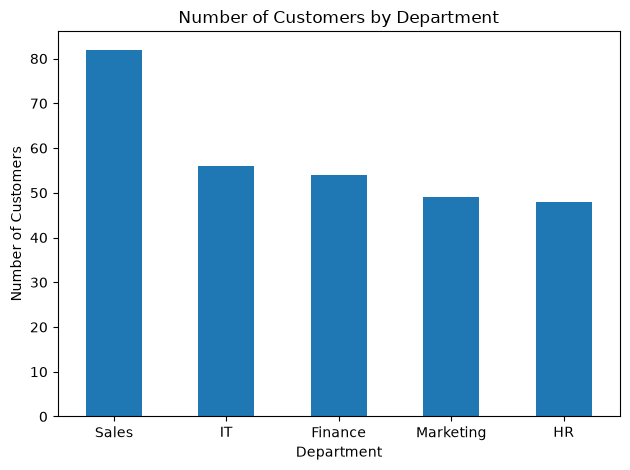

In [19]:
df["Department"].value_counts().plot(kind="bar")
plt.title("Number of Customers by Department")
plt.xlabel("Department")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. Save the cleaned dataset

The cleaned data is saved to a new file. The original `messy_customer_data.csv` remains unchanged.

In [20]:
output_file = "clean_customer_data.csv"
df.to_csv(output_file, index=False)

print("Cleaned dataset saved as:", output_file)

Cleaned dataset saved as: clean_customer_data.csv


## Conclusion

The dataset was cleaned by removing exact duplicate rows, standardising text and dates, converting numeric values, handling missing data, checking outliers with the IQR method and correcting data types. The cleaned data was saved separately so the original messy dataset is preserved.